# ChemAI: Predict the Cure

Ссылка на соревнование: https://www.kaggle.com/competitions/chem-ai-predict-the-cure/overview

### Описание задачи:
Разработка новых лекарственных препаратов - сложный и длительный процесс, включающий синтез соединений и их биологическое тестирование. Современные методы машинного обучения позволяют ускорить этот процесс, предсказывая эффективность химических соединений до проведения лабораторных экспериментов.

В этом соревновании предстоит выступить в роли ML инженеров в команде фармацевтической разработки.

Химики предоставили данные о свойствах молекул и их биологической активности против вируса гриппа. Задача - построить модели, способные предсказывать эффективность новых соединений.

Для каждого химического соединения необходимо предсказать три показателя:  
IC50 (mM) - концентрация, при которой вещество подавляет 50% активности вируса.  
CC50 (mM) - концентрация, при которой вещество токсично для 50% клеток.  
SI (Selectivity Index) - индекс селективности.

По условию задания допускается обучать одну multi-target модель или отдельные модели для каждой переменной.

### Описание датасета:
В соревновании используются данные о 1000 химических соединениях, описанных с помощью числовых молекулярных дескрипторов.

Данные разделены на:  
train.csv - 751 объект с известными значениями целевых переменных.  
test.csv - 250 объектов, для которых необходимо сделать предсказания.

В обучающей выборке представлены три целевые переменные:  
IC50 - концентрация вещества, при которой подавляется 50% биологической активности.  
CC50 - концентрация, при которой наблюдается токсичность для 50% клеток.  
SI (Selectivity Index) - индекс селективности, характеризующий эффективность соединения.

SI связан с IC50 и CC50, однако в рамках соревнования его необходимо предсказывать как отдельную переменную.

### Описание признаков:
Каждое химическое соединение описывается 214 числовыми признаками, отражающими его физико-химические, структурные и электронные свойства.

Признаки можно условно разделить на несколько групп:

1. Общие молекулярные свойства (MolWt, ExactMolWt, HeavyAtomMolWt, NumValenceElectrons, NumRadicalElectrons, MolLogP, MolMR, TPSA, LabuteASA,...).

2. Электронные и зарядовые характеристики (MaxPartialCharge, MinPartialCharge, MaxAbsPartialCharge, MinAbsPartialCharge, PEOE_VSA* - дескрипторы, связанные с распределением электронной плотности)

3. Топологические и структурные дескрипторы (Chi*, Kappa*, BalabanJ, BertzCT, HallKierAlpha, Ipc, FractionCSP3, RingCount, ...).

4. Поверхностные дескрипторы (VSA) (SMR_VSA*, SlogP_VSA*, EState_VSA*, VSA_EState*, ...).

5. Функциональные группы (fr_*) (Бинарные признаки, отражающие наличие различных химических групп: fr_alkyl_halide, fr_ester, fr_ether, fr_ketone, fr_benzene, fr_pyridine, fr_imidazole, fr_amide, fr_amine, fr_nitro, fr_halogen и многие другие).

6. Специфические дескрипторы (EState индексы (MaxEStateIndex, MinEStateIndex и др.), BCUT2D_* - спектральные дескрипторы, FpDensityMorgan* - плотности молекулярных отпечатков).

### Исполнители Team18:
- Сергей Когай
- Сергей Денисов
- Степан Заремба
- Матвей Гореликов
- Михаил Буланкин

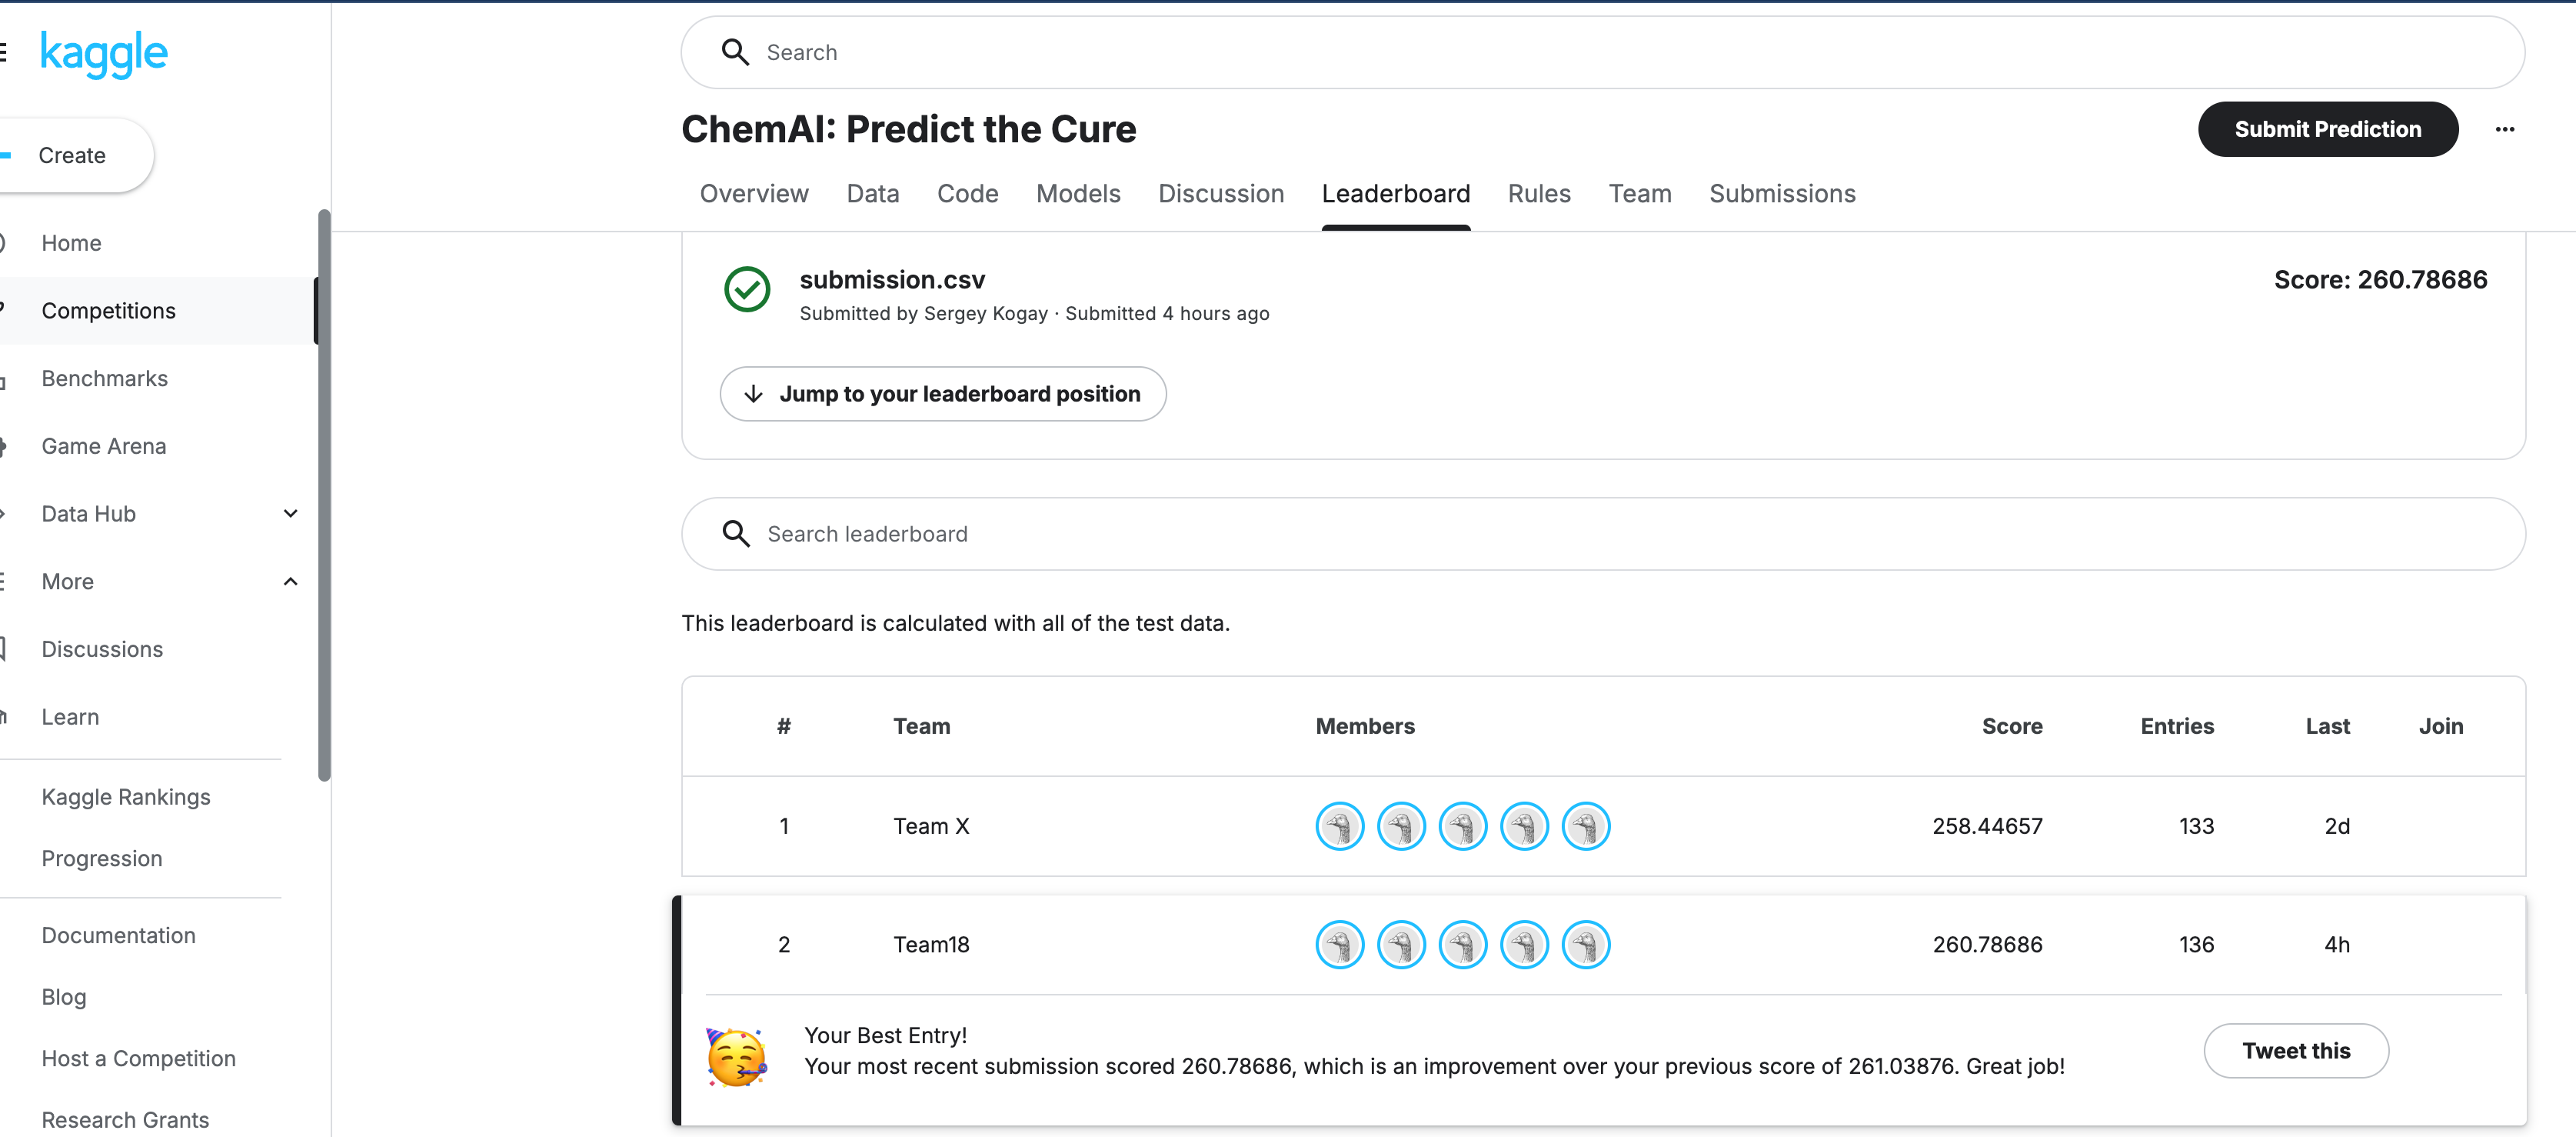

In [1]:
from IPython.display import Image
Image(filename='score.png')

In [2]:
# Импортируем библиотеки.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer

from skopt import BayesSearchCV
from skopt.space import Integer, Categorical

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

RANDOM_STATE = 42

In [3]:
# Загружаем данные.
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample_submission = pd.read_csv('sample_submission.csv')

# Первичный EDA

Цели анализа:

- проверить размерность данных и убедиться, что признаки представлены числовыми значениями;
- оценить масштабы признаков, так как молекулярные дескрипторы могут иметь сильно разные диапазоны;
- заметить признаки с нулевой или очень низкой вариативностью;
- увидеть потенциальные выбросы и оценить распределение целевых переменных;
- проверить наличие дубликатов.

In [4]:
# Первичный обзор признаков.
display(train.describe().T.head(20))

,count,mean,std,min,25%,50%,75%,max
index,751.0,375.000000,216.939316,0.000000,187.500000,375.000000,562.500000,750.000000
"IC50, mM",751.0,204.544021,370.367937,0.003517,13.222351,44.069306,206.787402,4095.188563
"CC50, mM",751.0,577.426098,641.515163,0.700808,99.998894,376.580899,877.508784,4538.976189
SI,751.0,89.153313,788.882198,0.011489,1.500000,4.000000,17.372463,15620.600000
MaxAbsEStateIndex,751.0,10.860070,3.347314,2.321942,8.921032,12.197500,13.214245,15.933463
MaxEStateIndex,751.0,10.860070,3.347314,2.321942,8.921032,12.197500,13.214245,15.933463
MinAbsEStateIndex,751.0,0.180064,0.169163,0.000039,0.048473,0.121372,0.290990,1.374614
MinEStateIndex,751.0,-0.971890,1.594491,-6.992796,-1.333831,-0.419485,0.072488,1.374614
qed,751.0,0.577938,0.214190,0.059567,0.442842,0.636477,0.742483,0.947265
SPS,751.0,29.588010,12.713195,9.545455,18.306020,29.281250,38.875000,60.272727


In [5]:
# Проверяем типы данных.
target_columns = ["IC50, mM", "CC50, mM", "SI"]

feature_columns = [
    col for col in train.columns
    if col not in target_columns + ["index"]
]

X_eda = train[feature_columns].copy()
y_eda = train[target_columns].copy()

print("Dataset shapes")
print("-" * 40)
print("Train shape:", train.shape)
print("Test shape: ", test.shape)
print("Number of feature columns:", len(feature_columns))
print("Number of target columns:", len(target_columns))

print("\nFeature dtypes")
print("-" * 40)
dtype_counts = X_eda.dtypes.value_counts()
display(dtype_counts)

non_numeric_features = X_eda.select_dtypes(exclude=[np.number]).columns.tolist()

print("\nNon-numeric feature columns:", len(non_numeric_features))
print(non_numeric_features)

print("\nTarget dtypes")
print("-" * 40)
display(y_eda.dtypes)

Dataset shapes
----------------------------------------
Train shape: (751, 214)
Test shape:  (250, 211)
Number of feature columns: 210
Number of target columns: 3

Feature dtypes
----------------------------------------


int64      106
float64    104
Name: count, dtype: int64


Non-numeric feature columns: 0
[]

Target dtypes
----------------------------------------


IC50, mM    float64
CC50, mM    float64
SI          float64
dtype: object

In [6]:
# Оцениваем масштабы признаков.
# Для каждого признака считаем min, median, max, std и range.
# Это помогает увидеть, насколько сильно отличаются диапазоны молекулярных дескрипторов.
feature_scale_summary = pd.DataFrame({
    "min": X_eda.min(),
    "median": X_eda.median(),
    "mean": X_eda.mean(),
    "max": X_eda.max(),
    "std": X_eda.std(),
})

feature_scale_summary["range"] = feature_scale_summary["max"] - feature_scale_summary["min"]
feature_scale_summary["abs_max"] = X_eda.abs().max()

display(
    feature_scale_summary
    .sort_values("range", ascending=False)
    .head(20)
)

,min,median,mean,max,std,range,abs_max
Ipc,107.107191,119977.905630,6.327782e+10,3.951781e+13,1.449887e+12,3.951781e+13,3.951781e+13
BertzCT,128.348516,668.171706,7.656501e+02,2.263926e+03,4.493009e+02,2.135578e+03,2.263926e+03
MolWt,110.156000,319.129000,3.524073e+02,9.047770e+02,1.290712e+02,7.946210e+02,9.047770e+02
ExactMolWt,110.073165,318.255880,3.520813e+02,9.042485e+02,1.289249e+02,7.941753e+02,9.042485e+02
HeavyAtomMolWt,100.076000,296.266000,3.283898e+02,8.563930e+02,1.240724e+02,7.563170e+02,8.563930e+02
TPSA,0.000000,50.520000,6.191278e+01,4.075000e+02,4.638150e+01,4.075000e+02,4.075000e+02
NumValenceElectrons,42.000000,122.000000,1.336272e+02,3.500000e+02,4.717366e+01,3.080000e+02,3.500000e+02
LabuteASA,46.234269,134.099489,1.484664e+02,3.533287e+02,5.325094e+01,3.070944e+02,3.533287e+02
EState_VSA5,0.000000,12.841643,1.935037e+01,2.703271e+02,2.283803e+01,2.703271e+02,2.703271e+02
SlogP_VSA2,0.000000,28.022038,3.362802e+01,2.131382e+02,2.411711e+01,2.131382e+02,2.131382e+02


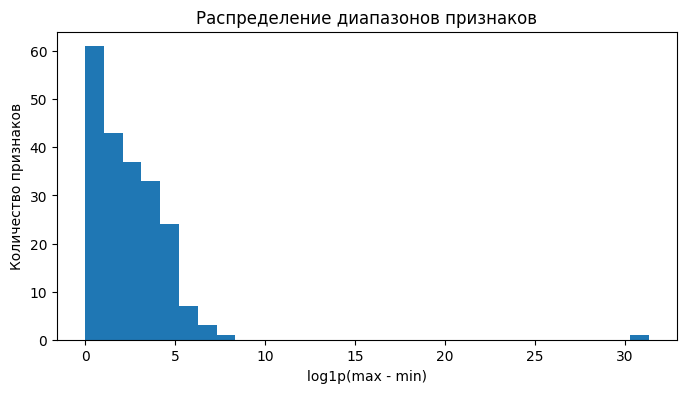

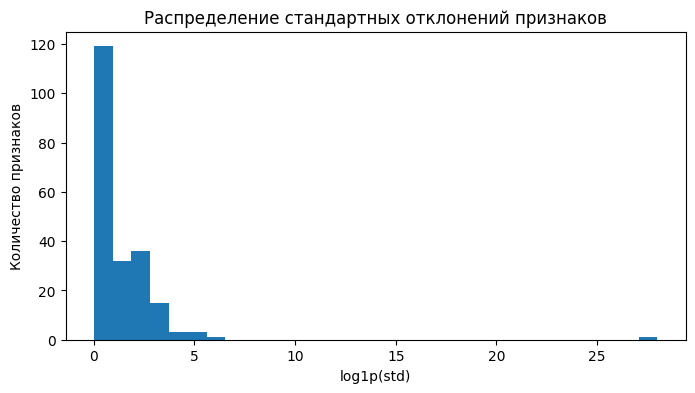

In [7]:
# Визуализируем распределение диапазонов признаков.
# Логарифмическая шкала удобна, так как молекулярные дескрипторы могут отличаться
# по масштабу на несколько порядков.
plt.figure(figsize=(8, 4))
plt.hist(np.log1p(feature_scale_summary["range"].fillna(0)), bins=30)
plt.title("Распределение диапазонов признаков")
plt.xlabel("log1p(max - min)")
plt.ylabel("Количество признаков")
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(np.log1p(feature_scale_summary["std"].fillna(0)), bins=30)
plt.title("Распределение стандартных отклонений признаков")
plt.xlabel("log1p(std)")
plt.ylabel("Количество признаков")
plt.show()

### Масштабы признаков

Анализ диапазонов признаков показал, что отдельные молекулярные дескрипторы имеют существенно большие значения по сравнению с остальными. Особенно выделяется признак `Ipc`: его максимум и диапазон на несколько порядков превышают значения большинства других признаков.

Такое поведение не обязательно является ошибкой. Некоторые топологические молекулярные дескрипторы могут иметь очень широкий диапазон значений, особенно если они зависят от размера и сложности структуры молекулы.

В качестве основной модели был выбран `RandomForestRegressor`. Для моделей на основе решающих деревьев различие масштабов признаков не является критичным, так как деревья используют пороговые разбиения по отдельным признакам, а не расстояния между объектами. Поэтому в отличие от линейных моделей, KNN, SVM или нейронных сетей случайный лес не требует обязательного масштабирования признаков.

По этой причине признак `Ipc` не был удалён только из-за большого масштаба. Вместо этого его полезность оценивалась вместе с остальными признаками на следующих этапах: через фильтрацию по вариативности, корреляционный анализ и важности признаков RandomForest.

In [8]:
# Проверяем признаки с нулевой или очень низкой вариативностью.
variance_summary = pd.DataFrame({
    "n_unique": X_eda.nunique(dropna=False),
    "variance": X_eda.var(),
    "std": X_eda.std(),
})

variance_summary["most_common_ratio"] = [
    X_eda[col].value_counts(dropna=False, normalize=True).iloc[0]
    for col in X_eda.columns
]

display(
    variance_summary
    .sort_values(["n_unique", "variance"], ascending=[True, True])
    .head(20)
)

,n_unique,variance,std,most_common_ratio
NumRadicalElectrons,1,0.000000,0.000000,1.000000
SMR_VSA8,1,0.000000,0.000000,1.000000
SlogP_VSA9,1,0.000000,0.000000,1.000000
fr_N_O,1,0.000000,0.000000,1.000000
fr_SH,1,0.000000,0.000000,1.000000
fr_azide,1,0.000000,0.000000,1.000000
fr_barbitur,1,0.000000,0.000000,1.000000
fr_benzodiazepine,1,0.000000,0.000000,1.000000
fr_diazo,1,0.000000,0.000000,1.000000
fr_dihydropyridine,1,0.000000,0.000000,1.000000


IC50, mM
----------------------------------------


count     751.000000
mean      204.544021
std       370.367937
min         0.003517
95.4%    1032.335012
99.7%    2188.788340
max      4095.188563
Name: IC50, mM, dtype: float64

95.45% quantile: 1032.3350 | values above: 35
99.73% quantile: 2188.7883 | values above: 3


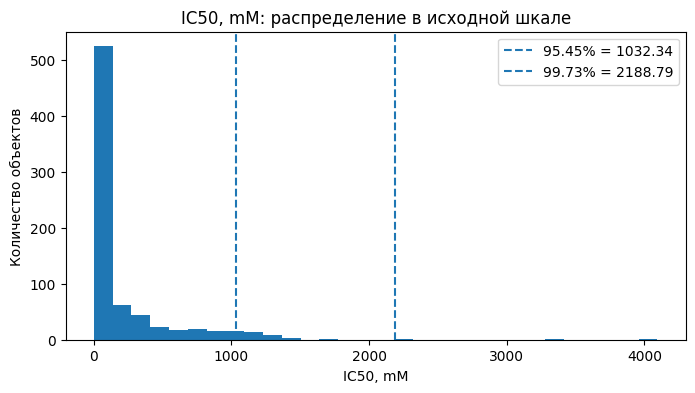

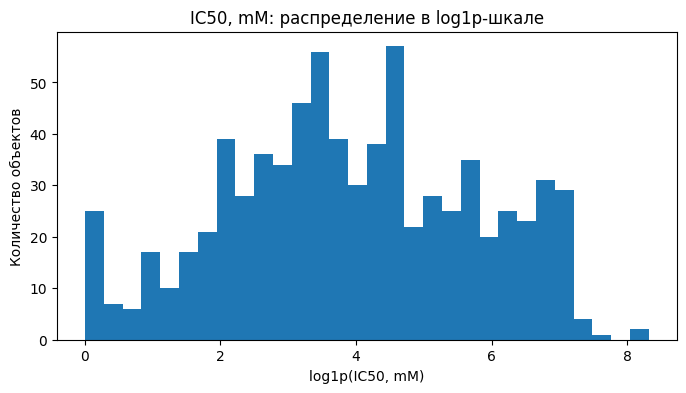

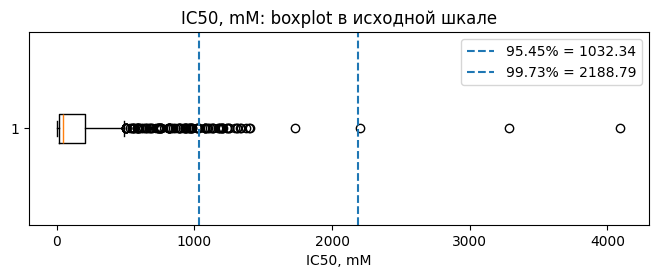

CC50, mM
----------------------------------------


count     751.000000
mean      577.426098
std       641.515163
min         0.700808
95.4%    1965.439708
99.7%    3919.295106
max      4538.976189
Name: CC50, mM, dtype: float64

95.45% quantile: 1965.4397 | values above: 33
99.73% quantile: 3919.2951 | values above: 3


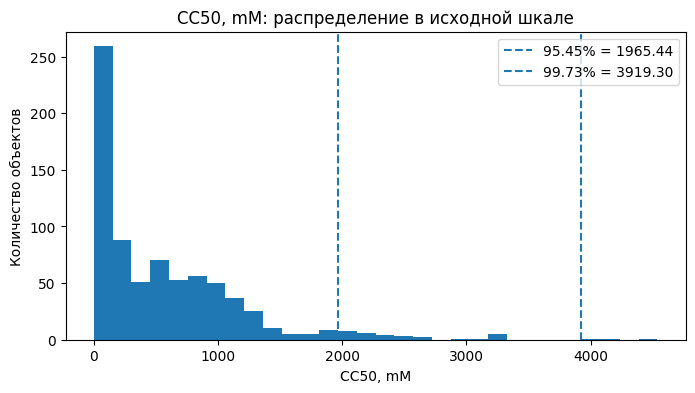

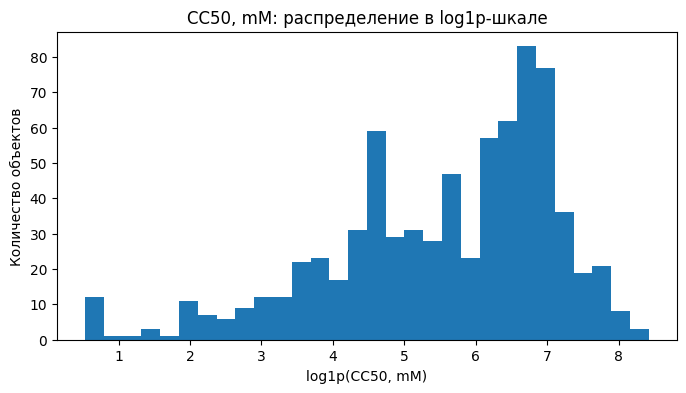

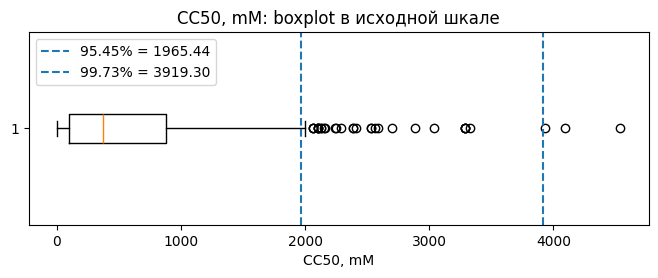

SI
----------------------------------------


count      751.000000
mean        89.153313
std        788.882198
min          0.011489
95.4%      159.506230
99.7%     5669.825000
max      15620.600000
Name: SI, dtype: float64

95.45% quantile: 159.5062 | values above: 35
99.73% quantile: 5669.8250 | values above: 3


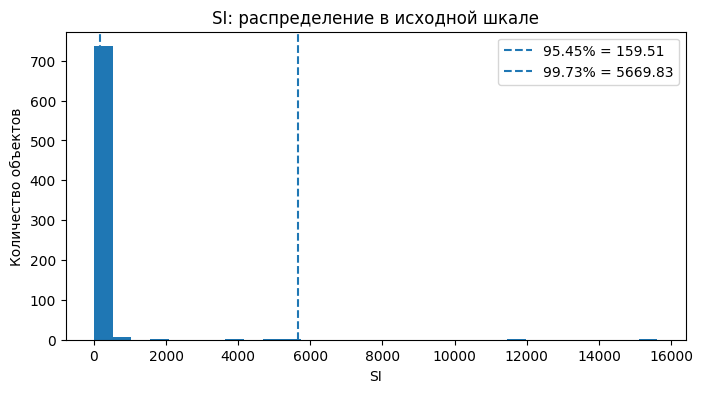

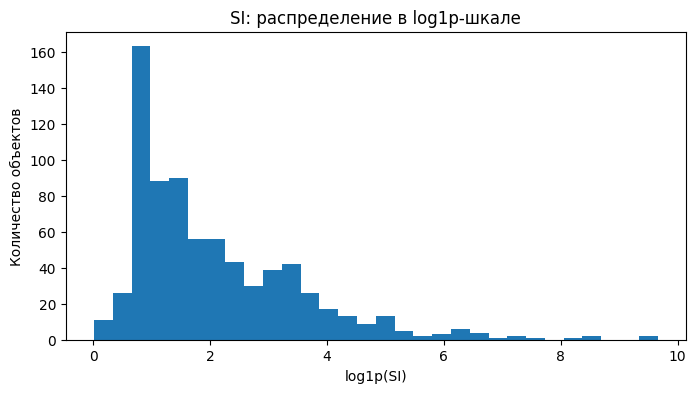

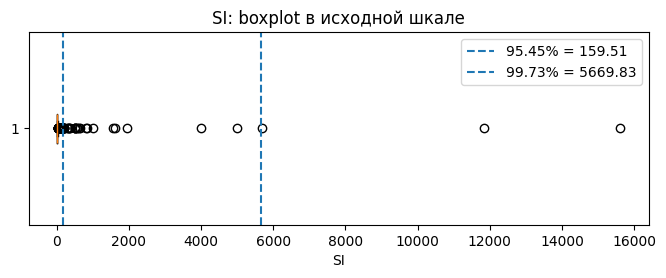

In [9]:
# Предварительно оцениваем распределения целевых переменных.
# Дополнительно смотрим распределения в log1p-шкале.
for target in target_columns:
    values = y_eda[target].dropna()
    log_values = np.log1p(values)

    q9545 = values.quantile(0.9545)
    q9973 = values.quantile(0.9973)

    n_above_q9545 = (values > q9545).sum()
    n_above_q9973 = (values > q9973).sum()

    print(target)
    print("-" * 40)
    display(values.describe(percentiles=[0.9545, 0.9973]))

    print(f"95.45% quantile: {q9545:.4f} | values above: {n_above_q9545}")
    print(f"99.73% quantile: {q9973:.4f} | values above: {n_above_q9973}")

    plt.figure(figsize=(8, 4))
    plt.hist(values, bins=30)
    plt.axvline(
        q9545,
        linestyle="--",
        label=f"95.45% = {q9545:.2f}"
    )
    plt.axvline(
        q9973,
        linestyle="--",
        label=f"99.73% = {q9973:.2f}"
    )
    plt.title(f"{target}: распределение в исходной шкале")
    plt.xlabel(target)
    plt.ylabel("Количество объектов")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.hist(log_values, bins=30)
    plt.title(f"{target}: распределение в log1p-шкале")
    plt.xlabel(f"log1p({target})")
    plt.ylabel("Количество объектов")
    plt.show()

    plt.figure(figsize=(8, 2.5))
    plt.boxplot(values, vert=False)
    plt.axvline(
        q9545,
        linestyle="--",
        label=f"95.45% = {q9545:.2f}"
    )
    plt.axvline(
        q9973,
        linestyle="--",
        label=f"99.73% = {q9973:.2f}"
    )
    plt.title(f"{target}: boxplot в исходной шкале")
    plt.xlabel(target)
    plt.legend()
    plt.show()

### Распределение целевых переменных и выбросы

Анализ распределений целевых переменных показал, что все таргеты имеют правостороннюю асимметрию, однако наиболее выраженная проблема наблюдается у `SI`.

Для `SI` среднее значение значительно превышает типичный уровень большинства наблюдений, а максимальное значение достигает `15620.6`. При этом 95.45% квантиль равен примерно `159.5`, а 99.73% квантиль — примерно `5669.8`. Это означает, что небольшое число экстремально больших значений формирует длинный правый хвост распределения.

Такие выбросы могут мешать обучению модели: RandomForestRegressor пытается учитывать редкие экстремальные значения, из-за чего качество предсказаний для основной массы объектов может ухудшаться. Особенно это важно, так как метрика соревнования основана на RMSE, а RMSE чувствительна к большим ошибкам на экстремальных значениях.

Были протестированы разные способы обработки выбросов, включая удаление строк с экстремальными значениями. Однако удаление объектов уменьшало размер обучающей выборки и приводило к менее стабильному качеству. Более устойчивым оказался клиппинг целевой переменной: экстремальные значения ограничиваются верхним порогом, но сами объекты остаются в обучении.

In [10]:
# Проверяем наличие дублирующихся строк.
# Отдельно анализируем:
# 1. дубли только по признаковому описанию молекул;
# 2. полные дубли по признакам и целевым переменным.
def check_duplicates(
    train,
    target_columns,
    id_columns,
):
    """
    Проверяет количество дублирующихся объектов в train.

    Логика:
    - id_columns исключаются из анализа, так как это технические идентификаторы;
    - feature_duplicates показывают молекулы с одинаковым признаковым описанием;
    - full_duplicates показывают полные дубли: одинаковые признаки и одинаковые target values.
    """

    protected_columns = list(target_columns) + list(id_columns)

    feature_columns = [
        col for col in train.columns
        if col not in protected_columns
    ]

    full_columns = feature_columns + list(target_columns)

    feature_duplicate_mask = train.duplicated(
        subset=feature_columns,
        keep=False
    )

    full_duplicate_mask = train.duplicated(
        subset=full_columns,
        keep=False
    )

    n_feature_duplicate_rows = feature_duplicate_mask.sum()
    n_full_duplicate_rows = full_duplicate_mask.sum()

    n_feature_duplicate_groups = (
        train.loc[feature_duplicate_mask, feature_columns]
        .drop_duplicates()
        .shape[0]
    )

    n_full_duplicate_groups = (
        train.loc[full_duplicate_mask, full_columns]
        .drop_duplicates()
        .shape[0]
    )

    print("Duplicate analysis")
    print("-" * 50)
    print("Rows:", train.shape[0])
    print("Features checked:", len(feature_columns))

    print("\nDuplicates by features only:")
    print("Duplicate rows:", n_feature_duplicate_rows)
    print("Duplicate groups:", n_feature_duplicate_groups)

    print("\nFull duplicates by features + targets:")
    print("Duplicate rows:", n_full_duplicate_rows)
    print("Duplicate groups:", n_full_duplicate_groups)

    duplicate_summary = pd.DataFrame({
        "duplicate_type": [
            "features_only",
            "features_and_targets",
        ],
        "duplicate_rows": [
            n_feature_duplicate_rows,
            n_full_duplicate_rows,
        ],
        "duplicate_groups": [
            n_feature_duplicate_groups,
            n_full_duplicate_groups,
        ],
    })

    display(duplicate_summary)

    return duplicate_summary

target_columns = ["IC50, mM", "CC50, mM", "SI"]

duplicate_summary = check_duplicates(
    train=train,
    target_columns=target_columns,
    id_columns=("index",),
)

Duplicate analysis
--------------------------------------------------
Rows: 751
Features checked: 210

Duplicates by features only:
Duplicate rows: 181
Duplicate groups: 60

Full duplicates by features + targets:
Duplicate rows: 28
Duplicate groups: 13


,duplicate_type,duplicate_rows,duplicate_groups
0,features_only,181,60
1,features_and_targets,28,13


### Дубликаты

В исходных данных были обнаружены дублирующиеся объекты:

- **181 строка** имеют дубли по признаковому описанию молекул;
- эти строки образуют **60 групп** одинаковых признаковых описаний;
- **28 строк** являются полными дублями, то есть совпадают не только признаки, но и все целевые переменные;
- полные дубли образуют **13 групп**.

Наличие дублей только по признакам, но с разными значениями целевых переменных может быть связано с экспериментальным шумом, повторными измерениями или тем, что одинаковое дескрипторное описание не всегда полностью отражает различия между соединениями и условиями эксперимента.

Были протестированы разные варианты обработки дублей: удаление полных дублей, удаление дублей по признакам и агрегация целевых переменных внутри групп. Однако эти подходы не улучшили качество модели на валидации и лидерборде.

Поэтому дубли были оставлены в обучающей выборке. Такое решение позволяет сохранить всю доступную информацию о наблюдениях, включая возможную вариативность экспериментальных измерений для молекул с одинаковыми признаковыми описаниями.

# Отбор признаков

По результатам первичного анализа дальнейшая обработка была направлена на удаление неинформативных признаков: константных, маловариативных и сильно скоррелированных дескрипторов.

In [11]:
# Удаляем константные признаки.
# Такие признаки имеют одно и то же значение для всех объектов train,
# поэтому не помогают модели различать соединения и могут только добавлять шум.
def remove_constant_features(
    train,
    test,
    target_columns,
    id_columns=("index",)
):
    """
    Удаляет константные признаки из train и test.

    Логика:
    - константные признаки ищутся только по train;
    - target_columns и id_columns не участвуют в отборе;
    - из test удаляются те же признаки, что и из train.
    """

    train_filtered = train.copy()
    test_filtered = test.copy()

    protected_columns = list(target_columns) + list(id_columns)

    train_feature_columns = [
        col for col in train_filtered.columns
        if col not in protected_columns
    ]

    constant_features = [
        col for col in train_feature_columns
        if train_filtered[col].nunique(dropna=False) <= 1
    ]

    train_shape_before = train_filtered.shape
    test_shape_before = test_filtered.shape

    train_filtered = train_filtered.drop(
        columns=constant_features,
        errors="ignore"
    )

    test_filtered = test_filtered.drop(
        columns=constant_features,
        errors="ignore"
    )

    print("Constant feature filtering")
    print("-" * 40)

    print("Dropped features:", len(constant_features))
    print(constant_features)

    print("\nTrain before:", train_shape_before)
    print("Train after: ", train_filtered.shape)

    print("\nTest before:", test_shape_before)
    print("Test after: ", test_filtered.shape)

    return train_filtered, test_filtered, constant_features

target_columns = ["IC50, mM", "CC50, mM", "SI"]

train, test, constant_features = remove_constant_features(
    train=train,
    test=test,
    target_columns=target_columns,
    id_columns=("index",)
)

Constant feature filtering
----------------------------------------
Dropped features: 18
['NumRadicalElectrons', 'SMR_VSA8', 'SlogP_VSA9', 'fr_N_O', 'fr_SH', 'fr_azide', 'fr_barbitur', 'fr_benzodiazepine', 'fr_diazo', 'fr_dihydropyridine', 'fr_isocyan', 'fr_isothiocyan', 'fr_lactam', 'fr_nitroso', 'fr_phos_acid', 'fr_phos_ester', 'fr_prisulfonamd', 'fr_thiocyan']

Train before: (751, 214)
Train after:  (751, 196)

Test before: (250, 211)
Test after:  (250, 193)


In [12]:
# Удаляем маловариативные признаки только среди НЕ fr_* признаков.
# Функциональные группы fr_* оставляем, потому что даже редкие фрагменты
# могут быть химически значимыми и улучшали качество на валидации/сабмите.
def remove_low_variance_non_fr_features(
    train,
    test,
    target_columns,
    id_columns,
    fr_prefix,
    variance_threshold,
):
    """
    Удаляет низковариативные признаки только среди НЕ fr_* признаков.

    Логика:
    - отбор признаков делается только по train;
    - fr_* признаки не удаляются;
    - target_columns и id_columns сохраняются;
    - test фильтруется тем же набором признаков, что и train.
    """

    train_filtered = train.copy()
    test_filtered = test.copy()

    protected_columns = list(target_columns) + list(id_columns)

    feature_columns = [
        c for c in train_filtered.columns
        if c not in protected_columns
    ]

    fr_features = [
        c for c in feature_columns
        if c.startswith(fr_prefix)
    ]

    other_features = [
        c for c in feature_columns
        if not c.startswith(fr_prefix)
    ]

    train_shape_before = train_filtered.shape
    test_shape_before = test_filtered.shape

    selector = VarianceThreshold(threshold=variance_threshold)

    selector.fit(train_filtered[other_features])

    selected_other_features = [
        feature
        for feature, keep in zip(other_features, selector.get_support())
        if keep
    ]

    removed_features = [
        feature
        for feature, keep in zip(other_features, selector.get_support())
        if not keep
    ]

    final_features = selected_other_features + fr_features

    train_columns_to_keep = (
        [c for c in id_columns if c in train_filtered.columns]
        + final_features
        + [c for c in target_columns if c in train_filtered.columns]
    )

    test_columns_to_keep = (
        [c for c in id_columns if c in test_filtered.columns]
        + final_features
    )

    train_filtered = train_filtered[train_columns_to_keep].copy()
    test_filtered = test_filtered[test_columns_to_keep].copy()


    print("Low-variance filtering for non-fr_* features")
    print("-" * 50)
    print("Variance threshold:", variance_threshold)

    print("\nTrain before:", train_shape_before)
    print("Train after: ", train_filtered.shape)

    print("\nTest before:", test_shape_before)
    print("Test after: ", test_filtered.shape)

    print("\nNon-fr_* features checked:", len(other_features))
    print("fr_* features kept without filtering:", len(fr_features))

    print("\nDropped features:", len(removed_features))
    print(removed_features)

    return train_filtered, test_filtered, removed_features, final_features

target_columns = ["IC50, mM", "CC50, mM", "SI"]

train, test, low_variance_features, final_features = remove_low_variance_non_fr_features(
    train=train,
    test=test,
    target_columns=target_columns,
    id_columns=("index",),
    fr_prefix="fr_",
    variance_threshold=0.01,
)

Low-variance filtering for non-fr_* features
--------------------------------------------------
Variance threshold: 0.01

Train before: (751, 196)
Train after:  (751, 194)

Test before: (250, 193)
Test after:  (250, 191)

Non-fr_* features checked: 122
fr_* features kept without filtering: 70

Dropped features: 2
['MinPartialCharge', 'MaxAbsPartialCharge']


In [13]:
# Удаляем сильно скоррелированные признаки.
# Для молекулярных дескрипторов это особенно актуально: многие признаки
# описывают близкие физико-химические свойства и частично дублируют друг друга.
def remove_highly_correlated_features(
    train,
    test,
    target_columns,
    id_columns,
    correlation_threshold,
):
    """
    Удаляет сильно скоррелированные признаки.

    Логика:
    - признаки анализируются только по train;
    - target_columns и id_columns не участвуют в отборе;
    - если два признака имеют |corr| >= correlation_threshold, удаляется один из них;
    - из test удаляются те же признаки, что и из train.
    """

    train_filtered = train.copy()
    test_filtered = test.copy()

    protected_columns = list(target_columns) + list(id_columns)

    feature_columns = [
        col for col in train_filtered.columns
        if col not in protected_columns
    ]

    train_shape_before = train_filtered.shape
    test_shape_before = test_filtered.shape

    X = train_filtered[feature_columns].copy()

    corr_matrix = X.corr(method="pearson").abs()

    upper_triangle = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    features_to_drop = [
        column
        for column in upper_triangle.columns
        if any(upper_triangle[column] >= correlation_threshold)
    ]

    train_filtered = train_filtered.drop(
        columns=features_to_drop,
        errors="ignore"
    )

    test_filtered = test_filtered.drop(
        columns=features_to_drop,
        errors="ignore"
    )

    final_features = [
        col for col in feature_columns
        if col not in features_to_drop
    ]

    print("Highly correlated feature filtering")
    print("-" * 50)
    print("Correlation threshold:", correlation_threshold)

    print("\nTrain before:", train_shape_before)
    print("Train after: ", train_filtered.shape)

    print("\nTest before:", test_shape_before)
    print("Test after: ", test_filtered.shape)

    print("\nFeatures checked:", len(feature_columns))
    print("Dropped features:", len(features_to_drop))
    print(features_to_drop)

    return train_filtered, test_filtered, features_to_drop, final_features

target_columns = ["IC50, mM", "CC50, mM", "SI"]

train, test, correlated_features, final_features = remove_highly_correlated_features(
    train=train,
    test=test,
    target_columns=target_columns,
    id_columns=("index",),
    correlation_threshold=0.96,
)

Highly correlated feature filtering
--------------------------------------------------
Correlation threshold: 0.96

Train before: (751, 194)
Train after:  (751, 164)

Test before: (250, 191)
Test after:  (250, 161)

Features checked: 190
Dropped features: 30
['MaxEStateIndex', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons', 'MinAbsPartialCharge', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'Kappa1', 'LabuteASA', 'SlogP_VSA6', 'HeavyAtomCount', 'NumHDonors', 'MolMR', 'fr_COO', 'fr_COO2', 'fr_C_O_noCOO', 'fr_Nhpyrrole', 'fr_benzene', 'fr_nitro_arom_nonortho', 'fr_phenol', 'fr_phenol_noOrthoHbond']


In [14]:
# Оцениваем важности признаков с помощью RandomForestRegressor.
# Этот шаг используется как model-based feature selection:
# признаки ранжируются по вкладу в деревьях случайного леса.
def get_rf_feature_importances(
    train,
    target_columns,
    id_columns,
    rf_params,
):
    """
    Обучает RandomForestRegressor и возвращает таблицу важностей признаков.

    Логика:
    - target_columns и id_columns исключаются из признаков;
    - RandomForestRegressor работает как multi-output model для IC50, CC50, SI;
    - feature_importances_ усреднены по деревьям и таргетам.
    """

    protected_columns = list(target_columns) + list(id_columns)

    feature_columns = [
        col for col in train.columns
        if col not in protected_columns
    ]

    X = train[feature_columns].copy()
    y = train[target_columns].copy()

    model = RandomForestRegressor(**rf_params)
    model.fit(X, y)

    importance_df = pd.DataFrame({
        "feature": feature_columns,
        "importance": model.feature_importances_,
    }).sort_values("importance", ascending=False).reset_index(drop=True)

    importance_df["rank"] = importance_df.index + 1
    importance_df["cumulative_importance"] = importance_df["importance"].cumsum()

    print("RandomForest feature importance")
    print("-" * 50)
    print("Features:", len(feature_columns))
    print("\nTop 10 features:")
    
    display(importance_df.head(10))

    return importance_df

target_columns = ["IC50, mM", "CC50, mM", "SI"]

rf_importance_df = get_rf_feature_importances(
    train=train,
    target_columns=target_columns,
    id_columns=("index",),
    rf_params={
        "n_estimators": 300,
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
    },
)

RandomForest feature importance
--------------------------------------------------
Features: 160

Top 10 features:


,feature,importance,rank,cumulative_importance
0,VSA_EState6,0.152564,1,0.152564
1,Kappa2,0.060559,2,0.213123
2,Kappa3,0.053068,3,0.266191
3,FpDensityMorgan1,0.048230,4,0.314420
4,Ipc,0.047786,5,0.362206
5,MolWt,0.038434,6,0.400641
6,BCUT2D_MWLOW,0.036064,7,0.436705
7,FpDensityMorgan2,0.026568,8,0.463272
8,BCUT2D_MRLOW,0.022375,9,0.485647
9,MaxPartialCharge,0.021328,10,0.506975


In [15]:
# Оставляем top-k признаков по важности RandomForest.
# Значение k подбиралось экспериментально по качеству модели.
def select_top_k_features_from_importance(
    train,
    test,
    importance_df,
    target_columns,
    top_k,
    id_columns,
):
    """
    Оставляет top_k признаков по RandomForest feature importance.

    Возвращает:
    - отфильтрованный train;
    - отфильтрованный test;
    - количество выбранных признаков;
    - количество удалённых признаков.
    """

    train_filtered = train.copy()
    test_filtered = test.copy()

    protected_columns = list(target_columns) + list(id_columns)

    feature_columns = [
        col for col in train_filtered.columns
        if col not in protected_columns
    ]

    selected_features = (
        importance_df
        .head(top_k)["feature"]
        .tolist()
    )

    removed_features = [
        col for col in feature_columns
        if col not in selected_features
    ]

    train_columns_to_keep = (
        [c for c in id_columns if c in train_filtered.columns]
        + selected_features
        + [c for c in target_columns if c in train_filtered.columns]
    )

    test_columns_to_keep = (
        [c for c in id_columns if c in test_filtered.columns]
        + selected_features
    )

    train_filtered = train_filtered[train_columns_to_keep].copy()
    test_filtered = test_filtered[test_columns_to_keep].copy()

    print("Top-k feature selection")
    print("-" * 50)
    print("Top k:", top_k)

    print("\nTrain after:", train_filtered.shape)
    print("Test after: ", test_filtered.shape)

    print("\nSelected features:", len(selected_features))
    print("Removed features:", len(removed_features))

    return train_filtered, test_filtered, selected_features, removed_features

train, test, selected_features, removed_features = select_top_k_features_from_importance(
    train=train,
    test=test,
    importance_df=rf_importance_df,
    target_columns=target_columns,
    id_columns=("index",),
    top_k=155,
)

Top-k feature selection
--------------------------------------------------
Top k: 155

Train after: (751, 159)
Test after:  (250, 156)

Selected features: 155
Removed features: 5


In [16]:
# Проверяем пропущенные значения после отбора признаков.
# Важно оценить не только количество пропусков, но и то,
# в каких именно дескрипторах они сосредоточены.
def check_missing(data, name):
    missing_count = data.isnull().sum()
    missing_count = missing_count[missing_count > 0].sort_values(ascending=False)

    missing_percent = (data.isnull().sum() / len(data)) * 100
    missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

    print(f'\n{name}')
    print('-' * 40)
    print(f'Размер данных: {data.shape}')
    print(f'Всего колонок с пропусками: {len(missing_count)}')
    print(f'Всего пропущенных значений: {data.isnull().sum().sum()}')

    if len(missing_count) > 0:
        missing_table = pd.DataFrame({
            'missing_count': missing_count,
            'missing_percent': missing_percent
        })

        display(missing_table)
    else:
        print('Пропусков нет')

check_missing(train, 'train')
check_missing(test, 'test')


train
----------------------------------------
Размер данных: (751, 159)
Всего колонок с пропусками: 9
Всего пропущенных значений: 18


,missing_count,missing_percent
BCUT2D_MWLOW,2,0.266312
BCUT2D_MRLOW,2,0.266312
MaxPartialCharge,2,0.266312
BCUT2D_MWHI,2,0.266312
BCUT2D_CHGLO,2,0.266312
BCUT2D_LOGPHI,2,0.266312
BCUT2D_CHGHI,2,0.266312
BCUT2D_LOGPLOW,2,0.266312
BCUT2D_MRHI,2,0.266312



test
----------------------------------------
Размер данных: (250, 156)
Всего колонок с пропусками: 9
Всего пропущенных значений: 9


,missing_count,missing_percent
BCUT2D_MWLOW,1,0.4
BCUT2D_MRLOW,1,0.4
MaxPartialCharge,1,0.4
BCUT2D_MWHI,1,0.4
BCUT2D_CHGLO,1,0.4
BCUT2D_LOGPHI,1,0.4
BCUT2D_CHGHI,1,0.4
BCUT2D_LOGPLOW,1,0.4
BCUT2D_MRHI,1,0.4


### Пропущенные значения

Пропуски обнаружены только в 9 признаках и составляют очень малую долю данных (2 строки в тренировочном датасете и одна строка в тестовом датасете). Все они относятся к одному типу молекулярных дескрипторов - в основном `BCUT2D_*`, а также `MaxPartialCharge`.

Вероятная причина таких пропусков - не случайное отсутствие данных, а невозможность корректного расчёта отдельных дескрипторов для некоторых молекул. Это может быть связано с особенностями химической структуры, зарядового состояния или ограничениями алгоритма расчёта дескрипторов.

Важно, что пропуски сосредоточены в небольшом числе объектов, а не распределены случайно по всему датасету. Поэтому сам факт отсутствия значения может нести информацию о специфике соединения. В связи с этим были протестированы разные стратегии заполнения пропусков (SimpleImputer и KNNImputer), однако они ухудшали качество модели, поэтому пропущенные значения были оставлены без явной иммутации.

In [17]:
# Определяем X и y для модели, а также X_test для предсказаний.
feature_columns = [
    c for c in train.columns
    if c not in target_columns + ["index"]
]

X = train[feature_columns].copy()
y = train[target_columns].copy()

X_test = test[feature_columns].copy()

In [18]:
# Применяем клиппинг целевых переменных.
# Верхние границы выбраны экспериментально: они ограничивают влияние редких экстремальных значений
# и при этом не удаляют объекты из обучающей выборки.
limits = {
    'CC50, mM': (0, 3500),
    'SI':       (0, 250),
}

y[list(limits)] = y[list(limits)].clip(
    lower={k: v[0] for k, v in limits.items()},
    upper={k: v[1] for k, v in limits.items()}
)

In [19]:
# Разбиваем данные на train и valid, обучаем модель и оцениваем качество на валидации.
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

model = RandomForestRegressor(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

model.fit(X_train, y_train)

valid_pred = model.predict(X_valid)

rmse_values = []

print('Validation scores:')

for i, target in enumerate(target_columns):
    mae = mean_absolute_error(y_valid.iloc[:, i], valid_pred[:, i])
    rmse = mean_squared_error(y_valid.iloc[:, i], valid_pred[:, i]) ** 0.5
    r2 = r2_score(y_valid.iloc[:, i], valid_pred[:, i])
    rmse_values.append(rmse)
    print(f'{target}: MAE={mae:.4f}, RMSE={rmse:.4f}, R2={r2:.4f}')

print("\nCompetition metric, mean RMSE:", np.mean(rmse_values))

model.fit(X, y)

pred = model.predict(X_test)

submission_columns = ['IC50', 'CC50', 'SI']

submission = sample_submission.copy()
submission[submission_columns] = pred

submission.to_csv('submission.csv', index=False)
print('Saved submission.csv')

Validation scores:
IC50, mM: MAE=191.5023, RMSE=385.1059, R2=0.1958
CC50, mM: MAE=275.9275, RMSE=403.6891, R2=0.4662
SI: MAE=18.0522, RMSE=33.6513, R2=0.3754

Competition metric, mean RMSE: 274.1487249752877
Saved submission.csv


# Обучение различных моделей, подбор гиперпараметров и кросс-валидация

По условию задачи были обучены несколько моделей и выполнен подбор гиперпараметров. В качестве кандидатов рассматривались `RandomForestRegressor` и `ExtraTreesRegressor`, а подбор параметров выполнялся с помощью `BayesSearchCV`.

Кросс-валидация использовалась как локальный инструмент сравнения моделей по метрике соревнования - среднему RMSE по трём целевым переменным: `IC50`, `CC50` и `SI`.

В ходе экспериментов `BayesSearchCV` выбрал модель `ExtraTreesRegressor`, которая показала лучший результат на кросс-валидации:

- `RandomForestRegressor`: CV mean RMSE ≈ `268.46`
- `ExtraTreesRegressor`: CV mean RMSE ≈ `267.14`

Однако при проверке на отложенной валидационной выборке и на лидерборде эта модель не превзошла более простую базовую конфигурацию:

`RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)`

Для простой модели результат на отложенной выборке составил:

- `IC50, mM`: RMSE ≈ `385.11`
- `CC50, mM`: RMSE ≈ `403.69`
- `SI`: RMSE ≈ `33.65`
- средний RMSE ≈ `274.15`

Для модели, выбранной через `BayesSearchCV`, результат оказался хуже:

- `IC50, mM`: RMSE ≈ `394.64`
- `CC50, mM`: RMSE ≈ `421.99`
- `SI`: RMSE ≈ `34.79`
- средний RMSE ≈ `283.81`

Таким образом, несмотря на лучший результат на кросс-валидации, модель после подбора гиперпараметров не дала улучшения на независимой проверке и на лидерборде. Вероятная причина - нестабильность кросс-валидации на данном датасете.

В данных присутствуют редкие (единичные), но очень сильные выбросы в целевых переменных. Так как таких объектов мало, при разбиении на несколько фолдов они могут распределяться неравномерно: в одном фолде может оказаться больше экстремальных значений, в другом - меньше. Это приводит к высокой дисперсии локальной оценки и может сделать результат кросс-валидации не полностью согласованным с качеством на лидерборде.

Поэтому финальный `submission.csv` был сформирован не моделью, автоматически выбранной по CV, а вручную выбранной конфигурацией, которая показала как лучшую локальную метрику так и лучший результат на лидерборде.

Возможные направления дальнейшего улучшения:

1. **Стабилизация кросс-валидации.**  
   Попробовать отдельно учитывать объекты с экстремальными значениями целевых переменных и контролировать их распределение по фолдам. Например, можно выделить строки с выбросами и следить, чтобы они не создавали сильный дисбаланс между обучающими и валидационными частями. Это должно снизить случайность оценки качества.

2. **Более аккуратная обработка выбросов целевых переменных.**  
   В текущем решении использовался простой клиппинг целевых переменных, который сделал модель стабильнее. Однако можно попробовать более химически согласованный подход. Поскольку индекс селективности связан с двумя другими показателями как:

   `SI = CC50 / IC50`

   при ограничении слишком больших значений `SI` можно не просто клиппить сам `SI`, а согласованно корректировать связанные таргеты. Например, если `SI` ограничивается верхним порогом, можно рассмотреть пропорциональное уменьшение `CC50`, увеличение `IC50` или комбинированную корректировку обоих значений так, чтобы сохранялось приближённое соотношение `SI = CC50 / IC50`.

   Такой подход потенциально может быть лучше простого клиппинга, так как он учитывает взаимосвязь между целевыми переменными, а не обрабатывает каждую из них полностью независимо.

In [21]:
def mean_rmse_3_targets(y_true, y_pred):
    rmse_per_target = []

    for i in range(y_true.shape[1]):
        rmse = mean_squared_error(
            y_true.iloc[:, i] if hasattr(y_true, "iloc") else y_true[:, i],
            y_pred[:, i]
        ) ** 0.5

        rmse_per_target.append(rmse)

    return np.mean(rmse_per_target)


rmse_scorer = make_scorer(
    mean_rmse_3_targets,
    greater_is_better=False,
)

cv = KFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE,
)

rf_model = RandomForestRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_search_space = {
    "n_estimators": Integer(250, 900),
    "max_depth": Categorical([None, 8, 10, 12, 15, 20, 25]),
    "min_samples_split": Integer(2, 12),
    "min_samples_leaf": Integer(1, 8),
    "max_features": Categorical(["sqrt", "log2", 0.3, 0.5, 0.7, 1.0]),
    "bootstrap": Categorical([True, False]),
}

et_model = ExtraTreesRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

et_search_space = {
    "n_estimators": Integer(250, 1000),
    "max_depth": Categorical([None, 8, 10, 12, 15, 20, 25]),
    "min_samples_split": Integer(2, 12),
    "min_samples_leaf": Integer(1, 8),
    "max_features": Categorical(["sqrt", "log2", 0.3, 0.5, 0.7, 1.0]),
    "bootstrap": Categorical([True, False]),
}

def run_bayes_search(
    model,
    search_space,
    X,
    y,
    cv,
    n_iter=50,
    random_state=RANDOM_STATE,
    model_name="model",
):
    search = BayesSearchCV(
        estimator=model,
        search_spaces=search_space,
        n_iter=n_iter,
        scoring=rmse_scorer,
        cv=cv,
        random_state=random_state,
        n_jobs=1,
        verbose=1,
        refit=True,
    )

    search.fit(X, y)

    print(model_name)
    print("-" * 40)
    print("Best CV MAE:", -search.best_score_)
    print("Best params:")
    print(search.best_params_)

    return search

rf_search = run_bayes_search(
    model=rf_model,
    search_space=rf_search_space,
    X=X,
    y=y,
    cv=cv,
    n_iter=50,
    random_state=RANDOM_STATE,
    model_name="RandomForestRegressor",
)

et_search = run_bayes_search(
    model=et_model,
    search_space=et_search_space,
    X=X,
    y=y,
    cv=cv,
    n_iter=50,
    random_state=RANDOM_STATE,
    model_name="ExtraTreesRegressor",
)

results = pd.DataFrame([
    {
        "model": "RandomForestRegressor",
        "best_cv_mean_rmse": -rf_search.best_score_,
        "best_params": rf_search.best_params_,
    },
    {
        "model": "ExtraTreesRegressor",
        "best_cv_mean_rmse": -et_search.best_score_,
        "best_params": et_search.best_params_,
    }
])

display(results.sort_values("best_cv_mean_rmse"))

best_search = rf_search if -rf_search.best_score_ <= -et_search.best_score_ else et_search
best_model_name = "RandomForestRegressor" if best_search is rf_search else "ExtraTreesRegressor"

print("Best model:", best_model_name)
print("Best CV mean RMSE:", -best_search.best_score_)
print(best_search.best_params_)

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

best_model = best_search.best_estimator_

best_model.fit(X_train, y_train)

valid_pred = best_model.predict(X_valid)

rmse_values = []

print("Validation scores:")

for i, target in enumerate(target_columns):
    rmse = mean_squared_error(y_valid.iloc[:, i], valid_pred[:, i]) ** 0.5
    mae = mean_absolute_error(y_valid.iloc[:, i], valid_pred[:, i])
    r2 = r2_score(y_valid.iloc[:, i], valid_pred[:, i])
    rmse_values.append(rmse)
    print(f"{target}: MAE={mae:.4f}, RMSE={rmse:.4f}, R2={r2:.4f}")

print("\nCompetition metric, mean RMSE:", np.mean(rmse_values))

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fi

/Users/mvl/code/mephi/unsupervised_learning/.venv/lib/python3.13/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.True_, np.int64(10), np.str_('sqrt'), np.int64(1), np.int64(2), np.int64(900)] before, using random point [False, 8, 0.5, np.int64(6), np.int64(12), np.int64(785)]
  warnings.warn(


Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits


/Users/mvl/code/mephi/unsupervised_learning/.venv/lib/python3.13/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.True_, np.int64(12), np.str_('sqrt'), np.int64(1), np.int64(2), np.int64(900)] before, using random point [True, 10, 0.5, np.int64(6), np.int64(4), np.int64(755)]
  warnings.warn(


Fitting 3 folds for each of 1 candidates, totalling 3 fits


...

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits


/Users/mvl/code/mephi/unsupervised_learning/.venv/lib/python3.13/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.True_, np.int64(12), np.str_('sqrt'), np.int64(1), np.int64(2), np.int64(900)] before, using random point [False, 20, 0.3, np.int64(5), np.int64(4), np.int64(865)]
  warnings.warn(


Fitting 3 folds for each of 1 candidates, totalling 3 fits
RandomForestRegressor
----------------------------------------
Best CV MAE: 268.45967255196706
Best params:
OrderedDict({'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 900})
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, 

,model,best_cv_mean_rmse,best_params
1,ExtraTreesRegressor,267.144472,"{'bootstrap': True, 'max_depth': 25, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 697}"
0,RandomForestRegressor,268.459673,"{'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 900}"


Best model: ExtraTreesRegressor
Best CV mean RMSE: 267.14447227458845
OrderedDict({'bootstrap': True, 'max_depth': 25, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 697})
Validation scores:
IC50, mM: MAE=190.6324, RMSE=394.6360, R2=0.1556
CC50, mM: MAE=296.2283, RMSE=421.9896, R2=0.4167
SI: MAE=19.1502, RMSE=34.7930, R2=0.3323

Competition metric, mean RMSE: 283.8062172608697
